In [7]:
import os
os.listdir("/kaggle/input")

['datasets']

In [9]:
print(os.listdir("/kaggle/input/datasets/varun000reddy/training/train/"))

['annos', 'image']


In [ ]:
import os
import json
from collections import Counter
from tqdm import tqdm

# Path to annotations folder
annos_path = "/kaggle/input/datasets/varun000reddy/training/train/annos"

category_counter = Counter()

# Loop through all annotation files
for file in tqdm(os.listdir(annos_path)):
    if file.endswith(".json"):
        with open(os.path.join(annos_path, file)) as f:
            data = json.load(f)
            
            # Each clothing item is stored as item1, item2, ...
            for key in data:
                if key.startswith("item"):
                    category_id = data[key]["category_id"]
                    category_counter[category_id] += 1

# Show all categories sorted
print("Category frequencies:")
for cat, count in category_counter.most_common():
    print(f"Category {cat} → {count}")

In [ ]:
top5 = category_counter.most_common(5)

print("\nTop 5 Categories:")
for cat, count in top5:
    print(f"Category {cat} → {count}")

In [ ]:
category_map = {
    1: "short sleeve top",
    2: "long sleeve top",
    3: "short sleeve outwear",
    4: "long sleeve outwear",
    5: "vest",
    6: "sling",
    7: "shorts",
    8: "trousers",
    9: "skirt",
    10: "short sleeve dress",
    11: "long sleeve dress",
    12: "vest dress",
    13: "sling dress"
}

print("\nTop 5 Category Names:")
for cat_id, count in top5:
    print(f"{category_map[cat_id]} → {count}")

In [1]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-03-07 07:20:58.021570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772868058.192540      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772868058.241337      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772868058.692990      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772868058.693026      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772868058.693029      55 computation_placer.cc:177] computation placer alr

In [3]:
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detected:", gpus)

GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
top5_ids = [1, 8, 7, 2, 9]
num_classes = 5

In [5]:
def load_filtered_dataset(image_dir, anno_dir, top5_ids):

    images = []
    labels = []

    json_files = sorted(os.listdir(anno_dir))

    for file in json_files:
        if not file.endswith(".json"):
            continue

        img_name = file.replace(".json", ".jpg")
        img_path = os.path.join(image_dir, img_name)

        

        label = np.zeros(len(top5_ids))
        contains_top5 = False

        with open(os.path.join(anno_dir, file)) as f:
            data = json.load(f)

        for key in data:
            if key.startswith("item"):
                cat_id = data[key]["category_id"]
                if cat_id in top5_ids:
                    idx = top5_ids.index(cat_id)
                    label[idx] = 1
                    contains_top5 = True

        if contains_top5:
            images.append(img_path)
            labels.append(label)

    print("Filtered dataset size:", len(images))
    return np.array(images), np.array(labels)

In [11]:
train_img_dir = "/kaggle/input/datasets/varun000reddy/training/train/image"
train_anno_dir = "/kaggle/input/datasets/varun000reddy/training/train/annos"

val_img_dir = "/kaggle/input/datasets/varun000reddy/validation/validation/image"
val_anno_dir = "/kaggle/input/datasets/varun000reddy/validation/validation/annos"

train_images, train_labels = load_filtered_dataset(
    train_img_dir, train_anno_dir, top5_ids
)

val_images, val_labels = load_filtered_dataset(
    val_img_dir, val_anno_dir, top5_ids
)

Filtered dataset size: 144174
Filtered dataset size: 23741


In [12]:
class_counts = np.sum(train_labels, axis=0)
total_samples = len(train_labels)

pos_weights = (total_samples - class_counts) / (class_counts + 1e-6)

print("Class counts:", class_counts)
print("Positive weights:", pos_weights)

Class counts: [70586. 54969. 36332. 35751. 30625.]
Positive weights: [1.04252968 1.62282377 2.96823737 3.03272636 3.70772245]


In [15]:
@tf.keras.utils.register_keras_serializable()
def weighted_binary_crossentropy(pos_weights):

    pos_weights_tensor = tf.constant(pos_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        weights = y_true * pos_weights_tensor + (1 - y_true)
        return tf.reduce_mean(bce * weights)

    return loss

In [16]:
IMG_SIZE = 224
BATCH_SIZE = 128   # Increased for 2 GPUs

def preprocess(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1772871301.672684      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772871301.678927      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [17]:
strategy = tf.distribute.MirroredStrategy()
print("Number of GPUs used:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs used: 2


In [ ]:
pos_weights = [1.04252968, 1.62282377, 2.96823737, 3.03272636, 3.70772245]

def weighted_binary_crossentropy(pos_weights):
    pos_weights_tensor = tf.constant(pos_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
        weights = y_true * pos_weights_tensor + (1 - y_true)
        return tf.reduce_mean(bce * weights)

    return loss

loss_fn = weighted_binary_crossentropy(pos_weights)



In [19]:
with strategy.scope():

    base_model = keras.applications.ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(224,224,3)
    )

    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512,activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(num_classes,activation="sigmoid")(x)

    model = keras.Model(base_model.input,outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=weighted_binary_crossentropy(pos_weights),
        metrics=["accuracy"]
    )

In [20]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "/kaggle/working/best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

In [21]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint]
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1772871470.874594     133 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772871470.905663     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


1127/1127 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.2934 - loss: 1.8719INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_loss improved from inf to 1.81731, saving model to /kaggle/working/best_model.keras
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 555s 468ms/step - accuracy: 0.2934 - loss: 1.8719 - val_accuracy: 0.3061 - val_loss: 1.8173
Epoch 2/10
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.3308 - loss: 1.7842
Epoch 2: val_loss improved from 1.81731 to 1.80842, saving model to /kaggle/working/best_model.keras
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 550s 474ms/step - accuracy: 0.3308 - loss: 1.7842 - val_accuracy: 0.3101 - val_loss: 1.8084
Epoch 3/10
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.3376 - loss: 1.7613
Epoch 3: val_loss

In [22]:
with strategy.scope():

    base_model.trainable = True

    for layer in base_model.layers[:-50]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(1e-5),
        loss=weighted_binary_crossentropy(pos_weights),
        metrics=["accuracy"]
    )

In [23]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    initial_epoch=10,
    callbacks=[checkpoint]
)

Epoch 11/35
INFO:tensorflow:Collective all_reduce tensors: 66 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.2750 - loss: 2.5152
Epoch 11: val_loss did not improve from 1.76343
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 772s 656ms/step - accuracy: 0.2750 - loss: 2.5150 - val_accuracy: 0.2644 - val_loss: 1.8852
Epoch 12/35
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.3121 - loss: 1.8369
Epoch 12: val_loss did not improve from 1.76343
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 742s 646ms/step - accuracy: 0.3121 - loss: 1.8368 - val_accuracy: 0.2443 - val_loss: 1.8009
Epoch 13/35
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.3333 - loss: 1.7292
Epoch 13: val_loss did not improve from 1.76343
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 745s 649ms/step - accuracy: 0.3333 - loss: 1.7292 - val_accuracy: 0.3908 - val_loss: 1.8334
Epoch 14/35
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/s

In [24]:
model.save('finetuning_epoch35.keras')

---
## ResNet Fine-tuning (continued training)

In [20]:
 model = tf.keras.models.load_model(
        '/kaggle/input/models/varun000reddy/resnet-finetune35eopch/keras/default/1/finetuning_epoch35.keras',
        compile=False
    )


In [22]:
trainable_layers = sum([layer.trainable for layer in model.layers])
total_layers = len(model.layers)

print(f"Trainable layers: {trainable_layers}")
print(f"Frozen layers: {total_layers - trainable_layers}")
print(f"Total layers: {total_layers}")

Trainable layers: 56
Frozen layers: 124
Total layers: 180


In [26]:
with strategy.scope():

    model = tf.keras.models.load_model(
        '/kaggle/input/models/varun000reddy/resnet-finetune35eopch/keras/default/1/finetuning_epoch35.keras',
        compile=False
    )


    # Reset
    for layer in model.layers:
        layer.trainable = True

    # Freeze first 80 → train last 100
    for layer in model.layers[:80]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(2e-5),
        loss=loss_fn,
        metrics=[
            "accuracy"
        ]
    )

In [27]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    initial_epoch=35,
    callbacks=[checkpoint]
)

Epoch 36/60
INFO:tensorflow:Collective all_reduce tensors: 122 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.2719 - loss: 2.3723
Epoch 36: saving model to /kaggle/working/latest_epoch.keras
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 900s 381ms/step - accuracy: 0.2719 - loss: 2.3721 - val_accuracy: 0.2590 - val_loss: 1.8105
Epoch 37/60
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.3256 - loss: 1.6922
Epoch 37: saving model to /kaggle/working/latest_epoch.keras
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 856s 373ms/step - accuracy: 0.3256 - loss: 1.6922 - val_accuracy: 0.2984 - val_loss: 1.7013
Epoch 38/60
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.3643 - loss: 1.5599
Epoch 38: saving model to /kaggle/working/latest_epoch.keras
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 869s 380ms/step - accuracy: 0.3643 - loss: 1.5599 - val_accuracy: 0.3373 - val_loss: 1.6282
Epoch 39/60
2

KeyboardInterrupt: 

In [31]:
with strategy.scope():

    # 1. Load latest checkpoint
    model = tf.keras.models.load_model(
        "/kaggle/working/latest_epoch.keras",
        compile=False
    )
    for layer in model.layers:
        layer.trainable = True

    total_layers = len(model.layers)
    freeze_until = total_layers - 120


    
    for layer in model.layers[:freeze_until]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss=loss_fn,
        metrics=[
            "accuracy"
        ]
    )

In [32]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "/kaggle/working/latest_epochfi.keras",
    save_best_only=False,   # 🔥 KEY CHANGE
    save_freq='epoch',      # save every epoch
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=74,
    initial_epoch=54,
    callbacks=[checkpoint]
)

Epoch 55/74
INFO:tensorflow:Collective all_reduce tensors: 146 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.3808 - loss: 1.9228
Epoch 55: saving model to /kaggle/working/latest_epochfi.keras
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 988s 419ms/step - accuracy: 0.3808 - loss: 1.9226 - val_accuracy: 0.4237 - val_loss: 1.8982
Epoch 56/74
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.5398 - loss: 0.7398
Epoch 56: saving model to /kaggle/working/latest_epochfi.keras
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 955s 416ms/step - accuracy: 0.5398 - loss: 0.7397 - val_accuracy: 0.4286 - val_loss: 2.7799
Epoch 57/74
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.5845 - loss: 0.3448
Epoch 57: saving model to /kaggle/working/latest_epochfi.keras
2253/2253 ━━━━━━━━━━━━━━━━━━━━ 1083s 470ms/step - accuracy: 0.5845 - loss: 0.3447 - val_accuracy: 0.4078 - val_loss: 3.0911
Epoch 

In [7]:
import tensorflow as tf

strategy = tf.distribute.MirroredStrategy()
print("Number of GPUs:", strategy.num_replicas_in_sync)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs: 2


In [8]:
from tensorflow.keras.models import load_model


model_path = "/kaggle/working/latest_epochfi.keras"
# OR model.h5
with strategy.scope():
  model = load_model(model_path, compile=False)

In [9]:
y_pred_probs = model.predict(val_ds)
y_pred_probs = np.array(y_pred_probs)

# Ground truth
y_true = np.concatenate([y for x, y in val_ds], axis=0)

I0000 00:00:1774704975.058319     120 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774704975.058309     122 cuda_dnn.cc:529] Loaded cuDNN version 91002


371/371 ━━━━━━━━━━━━━━━━━━━━ 72s 177ms/step


In [10]:
threshold = 0.5
y_pred = (y_pred_probs >= threshold).astype(int)

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)
f1_per_class = f1_score(y_true, y_pred, average=None)

for i in range(len(precision_per_class)):
    print(f"Class {i}:")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall:    {recall_per_class[i]:.4f}")
    print(f"  F1-score:  {f1_per_class[i]:.4f}")

Class 0:
  Precision: 0.7337
  Recall:    0.6029
  F1-score:  0.6619
Class 1:
  Precision: 0.7515
  Recall:    0.7975
  F1-score:  0.7738
Class 2:
  Precision: 0.5130
  Recall:    0.5638
  F1-score:  0.5372
Class 3:
  Precision: 0.4750
  Recall:    0.4474
  F1-score:  0.4608
Class 4:
  Precision: 0.6550
  Recall:    0.5610
  F1-score:  0.6044


In [14]:
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_micro = precision_score(y_true, y_pred, average='micro')
recall_micro = recall_score(y_true, y_pred, average='micro')
f1_micro = f1_score(y_true, y_pred, average='micro')

print("\n===== MACRO =====")
print("Precision:", precision_macro)
print("Recall:   ", recall_macro)
print("F1-score: ", f1_macro)

print("\n===== MICRO =====")
print("Precision:", precision_micro)
print("Recall:   ", recall_micro)
print("F1-score: ", f1_micro)


===== MACRO =====
Precision: 0.625633009552507
Recall:    0.5945015553434796
F1-score:  0.607601285440842

===== MICRO =====
Precision: 0.6584449207984188
Recall:    0.6157290500611772
F1-score:  0.636370974251352


In [15]:
from sklearn.metrics import roc_auc_score

num_classes = y_true.shape[1]

for i in range(num_classes):
    auc = roc_auc_score(y_true[:, i], y_pred_probs[:, i])
    print(f"Class {i} AUC: {auc:.4f}")

Class 0 AUC: 0.7493
Class 1 AUC: 0.8906
Class 2 AUC: 0.8254
Class 3 AUC: 0.7287
Class 4 AUC: 0.8312


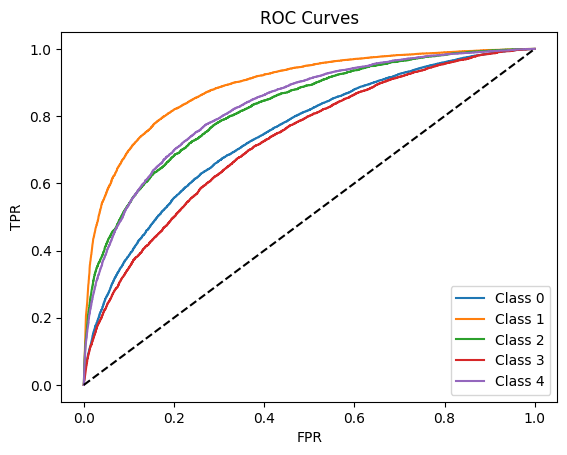

In [16]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'Class {i}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves")
plt.legend()
plt.show()